Trial 30 Complete [00h 01m 28s]
val_accuracy: 0.9255833625793457

Best val_accuracy So Far: 0.9268333315849304
Total elapsed time: 00h 20m 10s

--- TUNING COMPLETE ---
Optimal Hyperparameters:
  - Filters Block 1  : 64
  - Filters Block 2  : 128
  - Use Block 3      : False
  - Dense Units      : 384
  - Dropout Rate     : 0.30000000000000004
  - Learning Rate    : 0.0001


Building and training the best model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8478 - loss: 0.4364 - val_accuracy: 0.8852 - val_loss: 0.3088
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8965 - loss: 0.2812 - val_accuracy: 0.9087 - val_loss: 0.2574
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9165 - loss: 0.2278 - val_accuracy: 0.9142 - val_loss: 0.2340
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9294 - loss: 0.1909 - val_accuracy: 0.9176 - val_loss: 0.2324
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accura

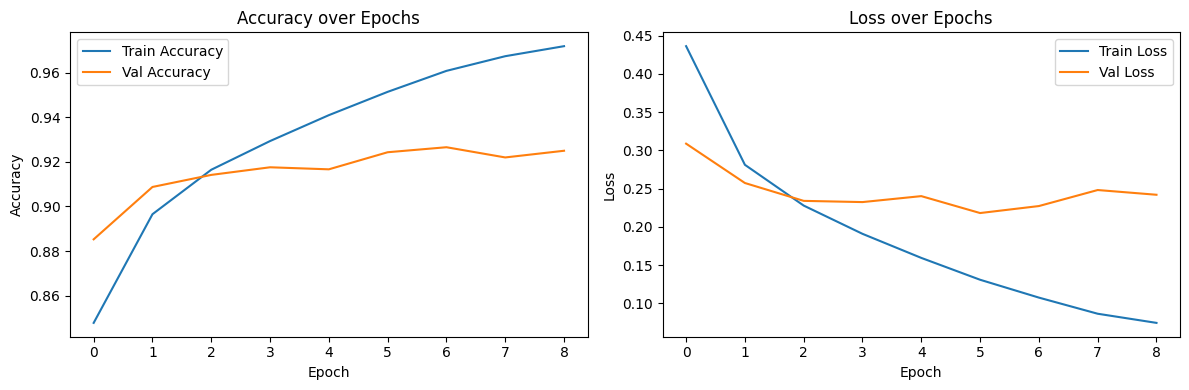

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


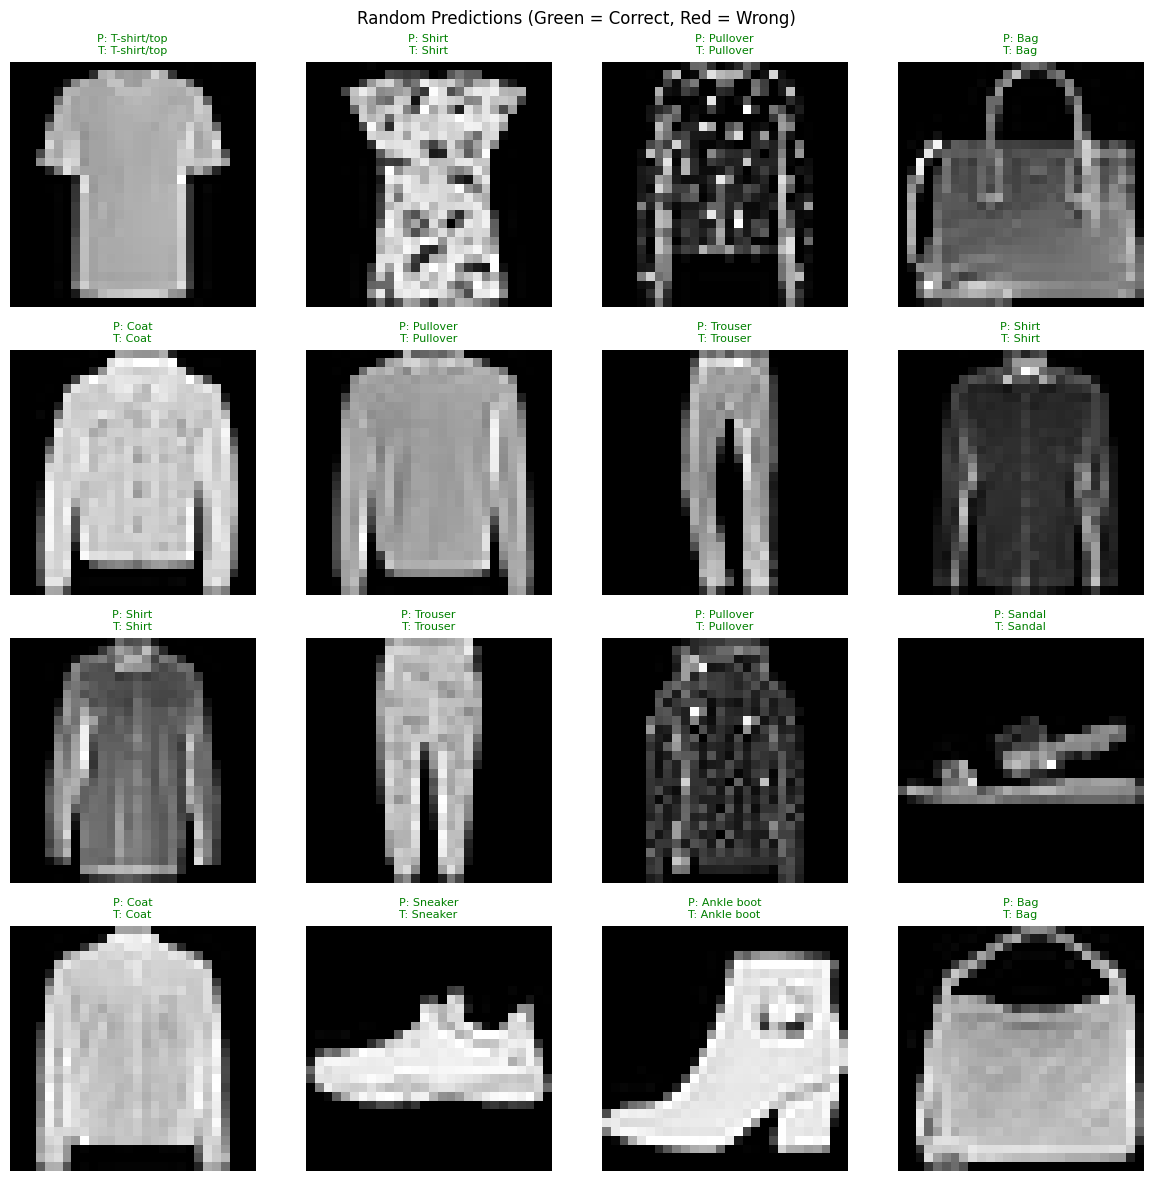

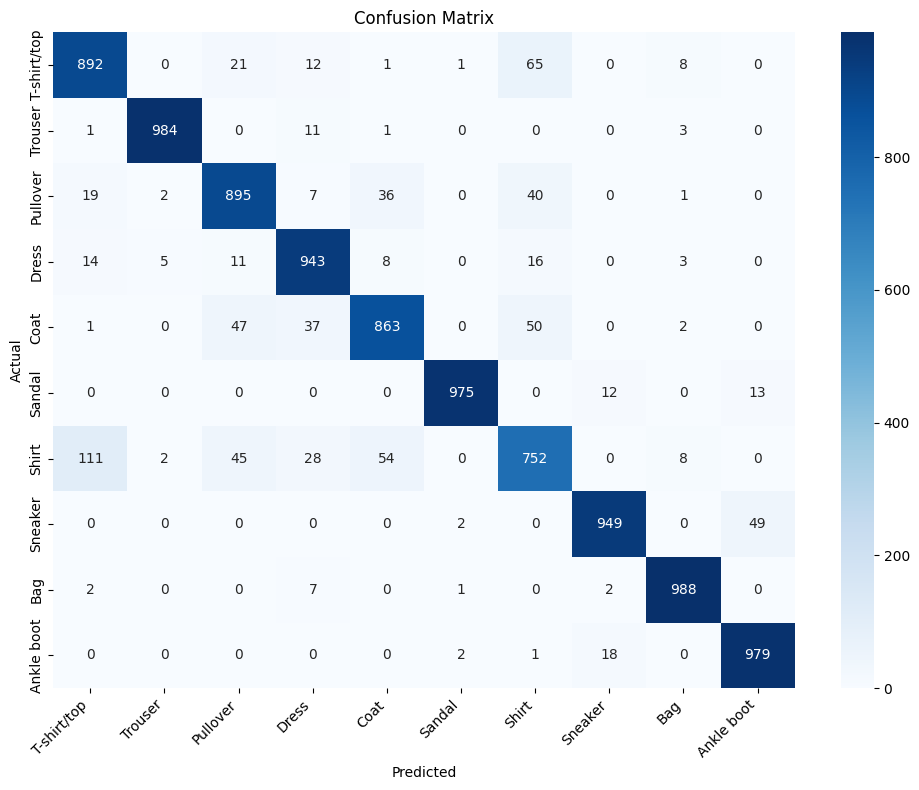

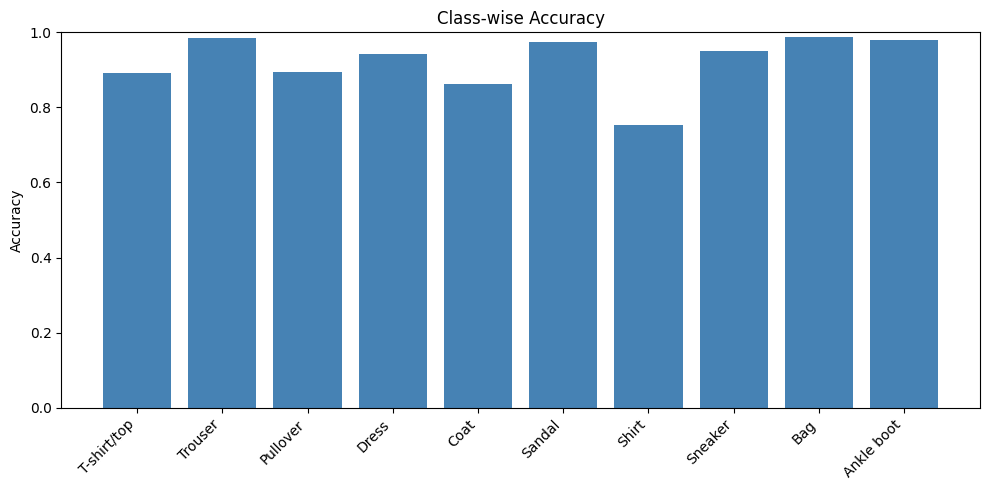

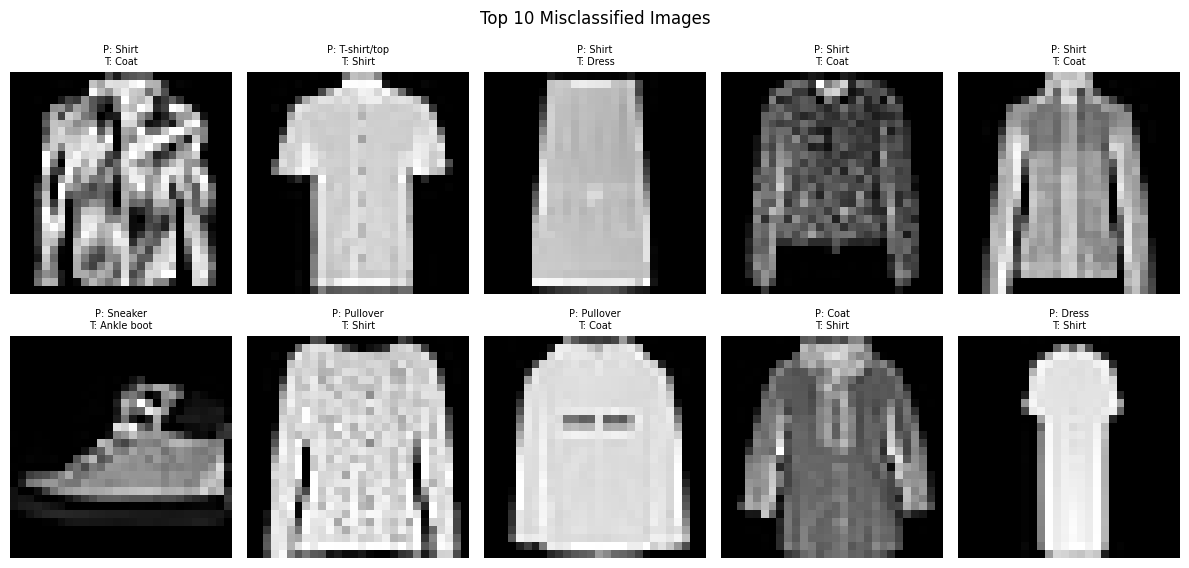

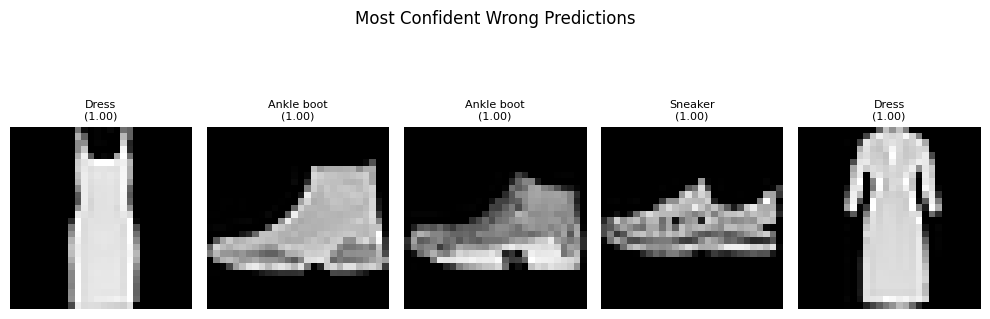


========== FINAL SUMMARY ==========
Dataset         : Fashion-MNIST
Train Samples   : 60000
Test Samples    : 10000
Image Shape     : (28, 28, 1)
Num Classes     : 10
Best Filters B1 : 64
Best Filters B2 : 128
Block 3 Used    : False
Dense Units     : 384
Dropout Rate    : 0.30000000000000004
Learning Rate   : 0.0001
Test Accuracy   : 0.9220
Test Loss       : 0.2667


In [1]:
# ============================================================
# ML & DL Experiment - CNN on Fashion-MNIST Dataset
# ============================================================

# STEP 0: Install Keras Tuner
!pip install keras-tuner -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# STEP 1: Load Fashion-MNIST Dataset
# ============================================================
print("Loading Fashion-MNIST Dataset...")

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Fashion-MNIST is grayscale (28x28x1), reshape to add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape:     {x_test.shape}")

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# ============================================================
# STEP 2: Visualize Sample Images
# ============================================================
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i][0]] if y_train[i].ndim > 0 else class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: Build CNN Model with Hyperparameter Tuning
# ============================================================
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # Block 1
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Block 2
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=32)
    model.add(layers.Conv2D(filters=hp_filters_2, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Optional Block 3
    if hp.Boolean('conv_block_3'):
        hp_filters_3 = hp.Int('filters_3', min_value=64, max_value=256, step=32)
        model.add(layers.Conv2D(filters=hp_filters_3, kernel_size=3, activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        # No MaxPooling here - image is already 7x7 after two pooling layers

    # Classifier Head
    model.add(layers.Flatten())
    hp_units = hp.Int('units', min_value=128, max_value=512, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# STEP 4: Hyperparameter Search with Hyperband
# ============================================================
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='fashion_tuner_dir',
    project_name='fashion_mnist_cnn'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("\nStarting Hyperparameter Search...")
tuner.search(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])

# ============================================================
# STEP 5: Print Best Hyperparameters
# ============================================================
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
--- TUNING COMPLETE ---
Optimal Hyperparameters:
  - Filters Block 1  : {best_hps.get('filters_1')}
  - Filters Block 2  : {best_hps.get('filters_2')}
  - Use Block 3      : {best_hps.get('conv_block_3')}
  - Dense Units      : {best_hps.get('units')}
  - Dropout Rate     : {best_hps.get('dropout')}
  - Learning Rate    : {best_hps.get('learning_rate')}
""")

# ============================================================
# STEP 6: Train the Best Model
# ============================================================
print("\nBuilding and training the best model...")
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[stop_early]
)

# ============================================================
# STEP 7: Evaluate on Test Set
# ============================================================
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# ============================================================
# STEP 8: Plot Accuracy & Loss Curves
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: Random Predictions (Green = Correct, Red = Wrong)
# ============================================================
pred_probs  = model.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = y_test.flatten()

plt.figure(figsize=(12, 12))
for i in range(16):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    color = "green" if pred_labels[idx] == true_labels[idx] else "red"
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}", color=color, fontsize=8)
    plt.axis('off')
plt.suptitle("Random Predictions (Green = Correct, Red = Wrong)")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: Confusion Matrix
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: Class-wise Accuracy Bar Chart
# ============================================================
class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_accuracy, color='steelblue')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 12: Top 10 Misclassified Images
# ============================================================
misclassified = np.where(pred_labels != true_labels)[0]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}", fontsize=7)
    plt.axis('off')
plt.suptitle("Top 10 Misclassified Images")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 13: Most Confident Wrong Predictions
# ============================================================
confidence = np.max(pred_probs, axis=1)
wrong_confidence = confidence[misclassified]
top_wrong = misclassified[np.argsort(-wrong_confidence)[:5]]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(top_wrong):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"{class_names[pred_labels[idx]]}\n({confidence[idx]:.2f})", fontsize=8)
    plt.axis('off')
plt.suptitle("Most Confident Wrong Predictions")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 14: Elbow Method (WCSS equivalent - just for reference)
# Print final summary
# ============================================================
print("\n========== FINAL SUMMARY ==========")
print(f"Dataset         : Fashion-MNIST")
print(f"Train Samples   : {x_train.shape[0]}")
print(f"Test Samples    : {x_test.shape[0]}")
print(f"Image Shape     : {x_train.shape[1:]}")
print(f"Num Classes     : 10")
print(f"Best Filters B1 : {best_hps.get('filters_1')}")
print(f"Best Filters B2 : {best_hps.get('filters_2')}")
print(f"Block 3 Used    : {best_hps.get('conv_block_3')}")
print(f"Dense Units     : {best_hps.get('units')}")
print(f"Dropout Rate    : {best_hps.get('dropout')}")
print(f"Learning Rate   : {best_hps.get('learning_rate')}")
print(f"Test Accuracy   : {test_acc:.4f}")
print(f"Test Loss       : {test_loss:.4f}")
print("====================================")